***Predictive Analysis***

***Question:***
*How do feature-rich apps (large size, multiple permissions, many functionalities) compare to lightweight apps in terms of user satisfaction, update frequency, and long-term retention across different categories?*

***This predictive analysis focuses on two primary objectives:***
- *Forecasting application install counts through regression modeling.*
- *Classifying applications based on their likelihood of achieving popularity.*

In [37]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [39]:
random_state = 42
np.random.seed(random_state)

In [40]:

path = kagglehub.dataset_download("vikaseranki9/google-play-store-cleaned")

print("Path to dataset files:", path)

csv_path = None
for file in os.listdir(path):
    if file.endswith(".csv"):
        csv_path = os.path.join(path, file)
        break

if csv_path is None:
    raise FileNotFoundError(f"No .csv file found in {path}")

df = pd.read_csv(csv_path)



Path to dataset files: /Users/saivikas/.cache/kagglehub/datasets/vikaseranki9/google-play-store-cleaned/versions/1


In [41]:
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]

In [42]:
df['installs'] = df['installs'].astype(str).str.replace('[+,]', '', regex=True).str.strip()
df['installs'] = pd.to_numeric(df['installs'], errors='coerce').fillna(0).astype(float)

In [43]:
if 'reviews' in df.columns:
    df['reviews'] = pd.to_numeric(df['reviews'], errors='coerce').fillna(0)

In [44]:
if 'rating' in df.columns:
    df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

In [45]:
df['installs_log'] = np.log1p(df['installs'])   # regression target
POPULARITY_THRESHOLD = 50_000
df['popular'] = (df['installs'] >= POPULARITY_THRESHOLD).astype(int)  # classification target

print("Popular ratio (1 = popular):")
print(df['popular'].value_counts(normalize=True))

Popular ratio (1 = popular):
popular
1    0.525062
0    0.474938
Name: proportion, dtype: float64


In [46]:
features = []
if 'category' in df.columns:
    features.append('category')
if 'rating' in df.columns:
    features.append('rating')
if 'reviews' in df.columns:
    features.append('reviews')
if 'price' in df.columns:
    features.append('price')
if 'size' in df.columns:
    features.append('size')

In [47]:
df_model = df[features + ['installs_log', 'popular']].copy()
df_model = df_model.dropna(subset=['installs_log'])
print("Prepared model dataframe shape:", df_model.shape)

Prepared model dataframe shape: (8479, 5)


In [48]:
numeric_cols = [c for c in features if c in df_model.columns and np.issubdtype(df_model[c].dtype, np.number)]
categorical_cols = [c for c in features if c in df_model.columns and c not in numeric_cols]


In [49]:
print("Numeric features:", numeric_cols)
print("Categorical features:", categorical_cols)

Numeric features: ['rating', 'reviews']
Categorical features: ['category']


In [50]:
X = df_model[features].copy()
if categorical_cols:
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

In [51]:
for c in numeric_cols:
    if X[c].isna().any():
        X[c] = X[c].fillna(X[c].median())

In [52]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

In [53]:
y_reg = df_model['installs_log']
y_clf = df_model['popular']

In [54]:
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=random_state, stratify=y_clf
)

In [55]:
print("Train/test shapes:", X_train.shape, X_test.shape)

Train/test shapes: (6783, 34) (1696, 34)


***Forecasting application install counts through regression modeling.***

In [56]:
lr = LinearRegression()
lr.fit(X_train, y_reg_train)
y_reg_pred_lr = lr.predict(X_test)

***Classifying applications based on their likelihood of achieving popularity.***

In [57]:
rf_reg = RandomForestRegressor(n_estimators=200, random_state=random_state, n_jobs=-1)
rf_reg.fit(X_train, y_reg_train)
y_reg_pred_rf = rf_reg.predict(X_test)

In [58]:
def eval_regression(y_true_log, y_pred_log, label="model"):
    true = np.expm1(y_true_log)
    pred = np.expm1(y_pred_log)

    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)

    mae = mean_absolute_error(true, pred)
    r2 = r2_score(y_true_log, y_pred_log)

    print(f"\n{label} — RMSE (installs): {rmse:,.2f} | MAE (installs): {mae:,.2f} | R2 (log target): {r2:.4f}")
    return true, pred


In [59]:
true_installs, pred_lr_installs = eval_regression(y_reg_test, y_reg_pred_lr, label="LinearRegression")
_, pred_rf_installs = eval_regression(y_reg_test, y_reg_pred_rf, label="RandomForestRegressor")


LinearRegression — RMSE (installs): 2,189,850.42 | MAE (installs): 730,744.82 | R2 (log target): 0.5621

RandomForestRegressor — RMSE (installs): 391,850.07 | MAE (installs): 187,631.84 | R2 (log target): 0.9195


In [60]:
rf_clf = RandomForestClassifier(n_estimators=200, random_state=random_state, n_jobs=-1)
rf_clf.fit(X_train, y_clf_train)
y_clf_pred = rf_clf.predict(X_test)

print("\nClassification results (RandomForestClassifier):")
print("Accuracy:", accuracy_score(y_clf_test, y_clf_pred))
print("\nClassification report:")
print(classification_report(y_clf_test, y_clf_pred, digits=3))
print("Confusion matrix:\n", confusion_matrix(y_clf_test, y_clf_pred))


Classification results (RandomForestClassifier):
Accuracy: 0.9428066037735849

Classification report:
              precision    recall  f1-score   support

           0      0.946     0.933     0.939       805
           1      0.940     0.952     0.946       891

    accuracy                          0.943      1696
   macro avg      0.943     0.942     0.943      1696
weighted avg      0.943     0.943     0.943      1696

Confusion matrix:
 [[751  54]
 [ 43 848]]


In [61]:
sns.set(style="whitegrid", context="notebook")

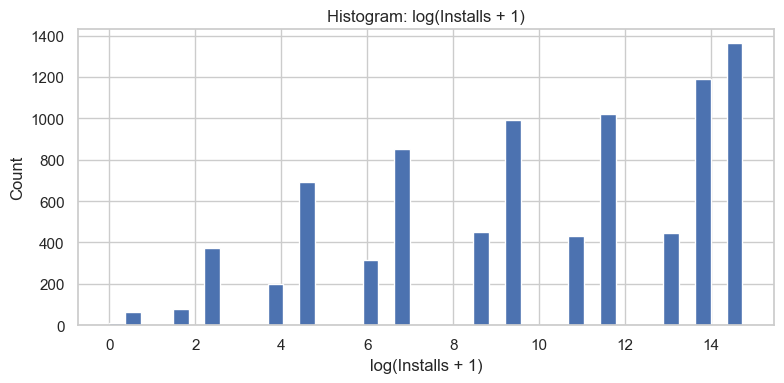

In [62]:
plt.figure(figsize=(8,4))
plt.hist(df['installs_log'].dropna(), bins=40)
plt.title("Histogram: log(Installs + 1)")
plt.xlabel("log(Installs + 1)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

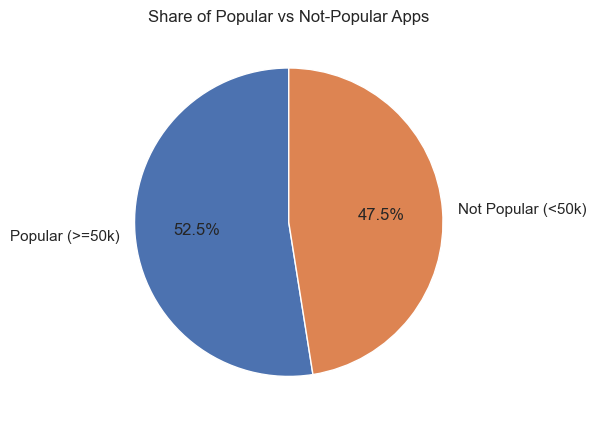

In [63]:
pop_counts = df['popular'].value_counts()
labels = ['Popular (>=50k)', 'Not Popular (<50k)']
plt.figure(figsize=(6,6))
plt.pie(pop_counts.values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Share of Popular vs Not-Popular Apps")
plt.tight_layout()
plt.show()


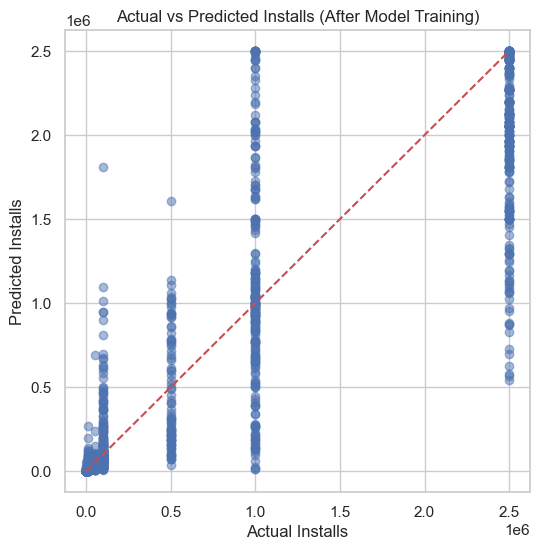

In [64]:
plt.figure(figsize=(6,6))
plt.scatter(true_installs, pred_rf_installs, alpha=0.5)
plt.plot([true_installs.min(), true_installs.max()],
         [true_installs.min(), true_installs.max()],
         'r--')  # diagonal perfect line
plt.xlabel("Actual Installs")
plt.ylabel("Predicted Installs")
plt.title("Actual vs Predicted Installs (After Model Training)")
plt.show()


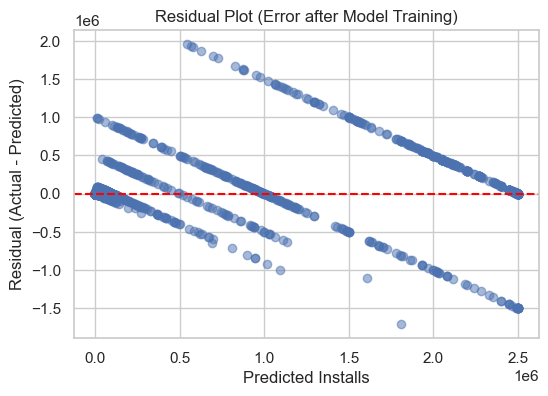

In [65]:
residuals = true_installs - pred_rf_installs

plt.figure(figsize=(6,4))
plt.scatter(pred_rf_installs, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Installs")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot (Error after Model Training)")
plt.show()


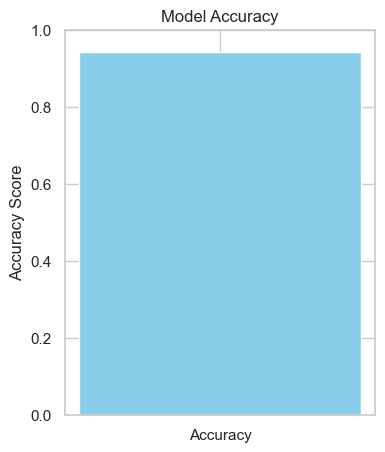

In [66]:
accuracy = accuracy_score(y_clf_test, y_clf_pred)

plt.figure(figsize=(4,5))
plt.bar(["Accuracy"], [accuracy], color='skyblue')
plt.ylim(0,1)
plt.title("Model Accuracy")
plt.ylabel("Accuracy Score")
plt.show()


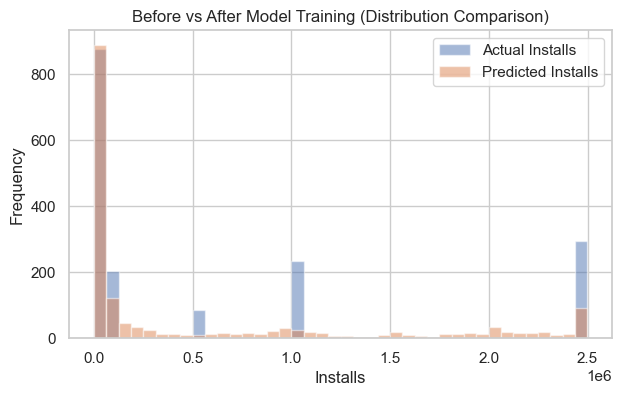

In [67]:
plt.figure(figsize=(7,4))

plt.hist(true_installs, bins=40, alpha=0.5, label="Actual Installs")
plt.hist(pred_rf_installs, bins=40, alpha=0.5, label="Predicted Installs")
plt.legend()
plt.title("Before vs After Model Training (Distribution Comparison)")
plt.xlabel("Installs")
plt.ylabel("Frequency")
plt.show()
